We are using the frost_sta_client Python package to query data from multiple SensorThings APIs at once. Find out more about the package [here](https://pypi.org/project/frost-sta-client/)

In [1]:
import frost_sta_client as fsc

# Get all things

In [2]:
def get_things_from_all_services(services, filter_expr=""):
    all_things = []

    for service in services:
        try:
            if filter_expr:
                things = service.things().query().filter(filter_expr).list()
            else:
                things = service.things().query().list()
            all_things.extend(things)
        except Exception as e:
            print(e)
            #print(f"Error querying {endpoint}: {e}")

    return all_things

Getting "Things" from all APIs, printing name and provider of each

In [3]:
APIS = {
    'NOC' : 'https://linkedsystems.uk/sensorthings/v1.1/',
    'BGS' : 'https://sensors.bgs.ac.uk/FROST-Server/v1.1/'
}

services = [fsc.SensorThingsService(endpoint) for endpoint in APIS.values()]

things_list = get_things_from_all_services(services)

for thing in things_list[:10]:
    print(f"{thing.name} - {thing.properties['provider']['name']}")

Atmospheric Measurement & Observation Facility - National Centre for Atmospheric Science
RRS Discovery Meteorology Platform - National Oceanography Centre
RRS Sir David Attenborough Meteorology Platform - British Antarctic Survey
RRS James Cook Meteorology Platform - National Oceanography Centre
BGS Groundwater Logger GGA01 - British Geological Survey
BGS Groundwater Logger GGA09r - British Geological Survey
BGS Groundwater Logger GGA08 - British Geological Survey
BGS Groundwater Logger GGA03r - British Geological Survey
BGS Groundwater Logger GGA05 - British Geological Survey
BGS Groundwater Logger GGB04 - British Geological Survey


# Getting all datastreams that measure air temperature

## Function to get datastreams from all Frost APIs

In [4]:
def get_datastreams_from_all_services(services, filter_expr=""):
    all_datastreams = []

    for service in services:
        try:
            if filter_expr:
                datastreams = service.datastreams().query().filter(filter_expr).list()
            else:
                datastreams = service.datastreams().query().list()
            all_datastreams.extend(datastreams)
        except Exception as e:
            print(e)
            #print(f"Error querying {endpoint}: {e}")

    return all_datastreams

In [5]:

datastreams_list = get_datastreams_from_all_services(services)

for datastream in datastreams_list[:10]:
    print(datastream.name)

Air Temperature
Air Temperature
Air Temperature
Air_Temperature
GGERFS_01 Barometric Pressure
GGA06R_01 TDS
GGA04_01 TDS
GGA06R_01 Water Temperature
GGB05_01 Conductivity
GGA03R_01 Water Temperature


**The datastream names are inconsistent and not very useful. Let's expand to include more useful attributes. Thing.name and observedProperty.name**

## Expanding to get more useful attributes of the datastreams

In [6]:
def get_datastreams_from_all_services(services, filter_expr=""):
    all_datastreams = []

    for service in services:
        try:
            if filter_expr:
                datastreams = service.datastreams().query().filter(filter_expr).expand('Thing,ObservedProperty').list()
            else:
                datastreams = service.datastreams().query().expand('Thing,ObservedProperty').list()
            all_datastreams.extend(datastreams)
        except Exception as e:
            print(e)
            #print(f"Error querying {endpoint}: {e}")

    return all_datastreams

datastreams_list = get_datastreams_from_all_services(services)

for datastream in datastreams_list[:10]:
    print(f" {datastream.thing.name} - {datastream.observed_property.name} - {datastream.unit_of_measurement.name} ")

 Atmospheric Measurement & Observation Facility - air_temperature - Degrees Celsius 
 RRS Discovery Meteorology Platform - air_temperature - Degrees Celsius 
 RRS Sir David Attenborough Meteorology Platform - air_temperature - Degrees Celsius 
 RRS James Cook Meteorology Platform - air_temperature - Degrees Celsius 
 BGS GGERFS Barometer - Barometric Pressure - Millibar 
 BGS Groundwater Logger GGA06r - TDS - milligrammes per litre 
 BGS Groundwater Logger GGA04 - TDS - milligrammes per litre 
 BGS Groundwater Logger GGA06r - Water Temperature - Degrees Celsius 
 BGS Groundwater Logger GGB05 - Conductivity - micro Siemens per centimetre 
 BGS Groundwater Logger GGA03r - Water Temperature - Degrees Celsius 


Now we have a much more usable list of available datastreams - The measuring platform, property and unit of measure.


Both APIs use Linked Data vocabularies to describe many entities, such as the ObservedProperties. So a good method to filter multiple APIs may be to search for where they both reference the same vocab record.

We know that both APIs reference [NERC Climate and Forecast Standard Names](http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/) and that the definiton of Air Temperature is http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/

In [7]:
definition = 'http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/'

datastreams_list = get_datastreams_from_all_services(services, f"ObservedProperty/definition eq '{definition}'")

for datastream in datastreams_list[:10]:
    print(f" {datastream.thing.name} - {datastream.observed_property.name} - {datastream.unit_of_measurement.name} ")

 Atmospheric Measurement & Observation Facility - air_temperature - Degrees Celsius 
 RRS Discovery Meteorology Platform - air_temperature - Degrees Celsius 
 RRS Sir David Attenborough Meteorology Platform - air_temperature - Degrees Celsius 
 RRS James Cook Meteorology Platform - air_temperature - Degrees Celsius 
 BGS GGERFS Barometer - Air Temperature - Degrees Celsius 


In [8]:
# get all things currently located in area of interest
things_list = get_things_from_all_services(services, "geo.intersects(Locations/location, geography'POLYGON ((2 50, 0 60, -15 55, -15 50, -10 40, -2 45, 2 50))')")

for thing in things_list[:10]:
    print(f"{thing.name} - {thing.properties['provider']['name']}")

Atmospheric Measurement & Observation Facility - National Centre for Atmospheric Science
RRS Discovery Meteorology Platform - National Oceanography Centre
RRS James Cook Meteorology Platform - National Oceanography Centre
BGS Groundwater Logger GGA01 - British Geological Survey
BGS Groundwater Logger GGA09r - British Geological Survey
BGS Groundwater Logger GGA08 - British Geological Survey
BGS Groundwater Logger GGA03r - British Geological Survey
BGS Groundwater Logger GGA05 - British Geological Survey
BGS Groundwater Logger GGB04 - British Geological Survey
BGS Groundwater Logger GGA06r - British Geological Survey


# Get all air temperature obvservations in the past week

In [9]:
def get_observations_from_all_services(services, filter_expr=""):
    all_observations = []

    for service in services:
        try:
            if filter_expr:
                #
                observations = service.observations().query().filter(filter_expr).top(10000).expand('Datastream,Datastream/ObservedProperty,Datastream/Thing').list()
            else:
                observations = service.datastreams().query().top(10000).list()
            all_observations.extend(observations)
        except Exception as e:
            print(f"Error querying {service}: {e}")

    return all_observations

# filtering by observed property is air temperature and phenomenonTime is in the last 7 days
#  - This can take a while, so if you want to see something quicker, then change duration to somethign smaller e.g. PT12H for last 12 hours
definition = 'http://vocab.nerc.ac.uk/collection/P07/current/CFSN0023/'
filter = f"Datastream/ObservedProperty/definition eq '{definition}' and phenomenonTime gt now() sub duration'P7D'"
observations_list = get_observations_from_all_services(services, filter)

for observation in observations_list[:10]:
    print(f" {observation.phenomenon_time} | {observation.datastream.thing.properties['provider']['name']} | {observation.datastream.thing.name} | {observation.result}")

 2025-10-02T11:02:00Z | National Centre for Atmospheric Science | Atmospheric Measurement & Observation Facility | 16.222
 2025-10-02T11:02:13.767Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:14.768Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:14.769Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:16.771Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:16.771Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:17.772Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:17.772Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:18.773Z | National Oceanography Centre | RRS Discovery Meteorology Platform | 16.79
 2025-10-02T11:02:18.773Z | National Oceanography Centre | RRS

## Plot last 7 days of air temperature

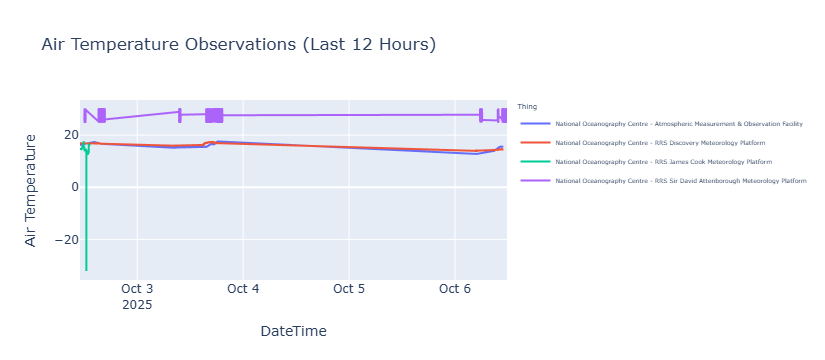

In [10]:
import pandas as pd
import plotly.express as px

# Flatten into a DataFrame
data = [{
    'datetime': pd.to_datetime(obs.phenomenon_time),
    'thing': observation.datastream.thing.properties['provider']['name'] + ' - ' + obs.datastream.thing.name,
    'result': obs.result
} for obs in observations_list]

df = pd.DataFrame(data)
df.sort_values(by='datetime', inplace=True)

fig = px.line(df, x='datetime', y='result', color='thing',
              labels={'datetime': 'DateTime', 'result': 'Air Temperature', 'thing': 'Thing'},
              title='Air Temperature Observations (Last 12 Hours)')

# Update layout to reduce font sizes
fig.update_layout(
    legend=dict(
        font=dict(size=6)  # Legend font size
    )
)

fig.show()


plot saved to be visible on github:

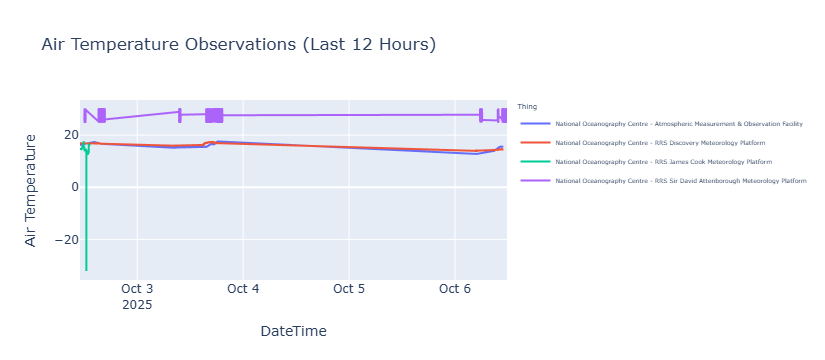

## Download last 7 days of air temperature to CSV

In [12]:

# Create DataFrame and save to CSV
df = pd.DataFrame(data)
df.to_csv('air_temperature_observations.csv', index=False)

print("Saved to air_temperature_observations.csv")


Saved to air_temperature_observations.csv
